# Train een worm om te kruipen

In deze notebook ga je aan de slag met versterkend leren. Je traint zelf een worm om te leren kruipen. 

De notebook bestaat uit de volgende stappen:
1. Je onderzoekt hoe een worm kruipt.
2. Je stelt de worm abstract voor door een reeks van segmenten.
3. Je legt vast wat **de agent**, **de omgeving**, **de toestand**, **de beloning** en **de acties** zijn.
4. Je gaat op zoek naar een optimaal **beleid** door een **waardefunctie** te leren op basis van de **beloningen**.



## Hoe kruipt een worm?

Je bent zeker al eens een worm tegengekomen wanneer je aan het graven was in de tuin. Heb je dan al eens stilgestaan bij hoe zo'n worm zich verplaatst onder de grond? Dat is niet zo evident, wormen hebben immers geen poten. Beeld je in dat we je omwikkelen met duct tape en we je begraven in de grond, kan je je dan nog verplaatsen?

### De morfologie van een worm

De **bouw en de vorm** van een organisme noemen we de **morfologie** van dat organisme. Deze morfologie zorgt ervoor dat de worm zich onder de grond kan verplaatsen. 

**Segmenten**

Een worm is opgebouwd uit afgescheiden segmenten die gevuld zijn met vocht.

![Segmenten van de worm](img/worm_base.png)

**Spieren**

Over de lengte van de worm lopen lengtespieren.

![Lengtespieren van de worm](img/worm_long_muscles.png)

Naast de lentespieren heeft de worm ook kringspieren die rondom het lichaam van de worm lopen.

![Kringspieren van de worm](img/worm_long_and_short_muscles.png)


**Haartjes**

Op het lichaam van de worm zitten ook kleine haartjes. Deze zorgen ervoor dat de worm meer grip heeft op de aarde er rondom.

### De bewegingen van de worm

De worm kan elk segment op twee mogelijke manieren bewegen.

**Samentrekken lengtespieren**

Door de lengtespieren in een segment samen te trekken wordt de lengte van het segment korter. Omdat het segment gevuld is met vocht en vocht niet samendrukbaar is, zorgt dat ervoor dat de buitenkant van de worm uitzet door de druk.

![Inkorten van een segment.](img/worm_contracted.png)

Omgekeerd door de kringspieren in een segment samen te trekken wordt de omtrek van het segment korter. Daardoor zal het segment door de druk langer worden.

![Uitzetten van een segment](img/worm_expanded_segment.png)

Een ingekort segment zorgt voor meer druk op de aarde rondom de worm. De haartjes op de worm grijpen op die plaats dus de aarde vast. Een uitgezet segment zorgt ervoor dat de worm langer en dunner wordt daardoor is er minder wrijving op de aarde rondom de worm en kan dat stuk zich makkelijker vooruit en achteruit bewegen.

Door de lengte- en kringspieren in een correct patroon samen te trekken en los te laten, kan de worm zich vooruit bewegen. Het is dit patroon dat we een virtuele worm zullen proberen te leren via versterkend leren.

# De virtuele worm

Voor we de virtuele worm aanmaken importeren we eerst de nodige bibliotheken. Zoals altijd hebben we al wat code geschreven om van te vertrekken. Zo kunnen we in deze notebook focussen op wat belangrijk is om de worm te trainen. Wil je graag die code bekijken dan kan dat in het bestand *scripts/helpers.py*.

In [35]:
from scripts.helpers import Worm, print_q_tabel, voer_policy_uit, maak_animatie_van_worm
from itertools import product
from scripts.questions import Questions
from IPython.display import HTML, Video
import numpy as np
import random
vragen = Questions()

Om het probleem wat te vereenvoudigen, stellen we onze worm voor als een lijst van segmenten. Elk segment kan ofwel lang zijn ofwel kort zijn. We laten de neutrale toestand van de spieren weg, zo zal het makkelijker zijn om een bewegingspatroon te leren. 

Voor de virtuele worm hebben we een klasse gemaakt. Deze bevat de lijst van segmenten en functies om een segment lang of kort te maken. Onderstaande code maakt een worm met 5 segmenten.

In [36]:
worm = Worm(5)

Wanneer we de worm afdrukken krijgen we een lijst van letters. Elke letter stelt de toestand van een segment voor, K voor kort en L voor lang. We hebben ervoor gekozen om alle segmenten kort te maken bij het creëren van een worm.

In [37]:
print(f"De starttoestand van de worm is: {worm}")

De starttoestand van de worm is: KKKKK


Het worm object heeft een aantal functies (methodes) die we kunnen gebruiken om de toestand van de worm te veranderen. De volgende code drukt die methodes af.

In [38]:
# Druk de af welke methodes de worm heeft
print("De worm heeft de volgende methodes:")
methodes = [method_naam for method_naam in dir(worm) if callable(getattr(worm, method_naam))]
for method in methodes:
    if not method.startswith("__"):
        print(f"- {method}")

De worm heeft de volgende methodes:
- maak_kopie
- maak_segment_korter
- maak_segment_langer
- positie_van_het_hoofd
- posities_van_de_segmenten
- segmenten
- teken_worm
- toestand
- toestand_kopie
- zit_segment_tussen_twee_korte_segmenten


Je merkt dat er een methode is om de worm te tekenen. Laten we die eens uitproberen.

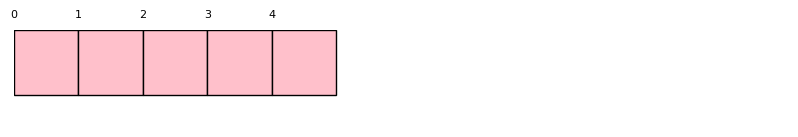

In [39]:
worm.teken_worm()

Je ziet dat alle elementen van de worm momenteel kort zijn. Met de methode `maak_segment_langer()` kan je een van de segmenten lang maken. Aan de methode geef je het nummer van het segment mee. De segmenten worden genummerd vanaf 0.

De worm is nu: KKKKL


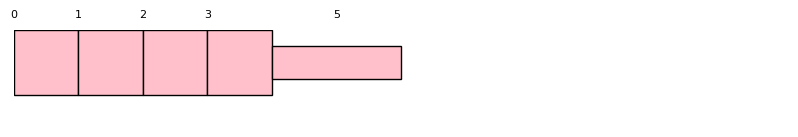

In [40]:
worm.maak_segment_langer(4)
print(f"De worm is nu: {worm}")
worm.teken_worm()

**Opmerking**

De korte segmenten zijn dik en drukken tegen de aarde rondom de worm. De haartjes van de worm grijpen de aarde zo vast. Bijgevolg is het niet mogelijk om een segment dat tussen twee korte segmenten zit, lang te maken. De worm zou in dat geval naar links of rechts moeten bewegen. Maar omdat aan beide zijden van het segment korte segmenten zijn, lukt dat niet. Je ziet bijvoorbeeld dat het langer maken van segment 2 geen effect heeft.

De worm is nu: KKKKL


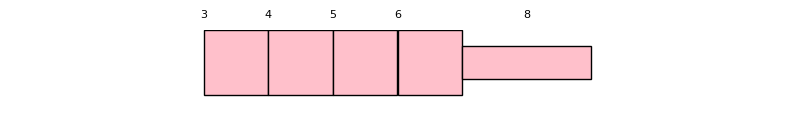

In [63]:
worm.maak_segment_langer(4)
print(f"De worm is nu: {worm}")
worm.teken_worm()

Door segmenten in het juiste patroon korter of langer te maken, kan de worm zich voortbewegen.

**Opdracht**: pas een sequentie van bewegingen toe op de worm en zorg er zo voor dat de staart van de worm twee posities naar rechts opschuift. Druk na elke verschuiving de worm af op het scherm.

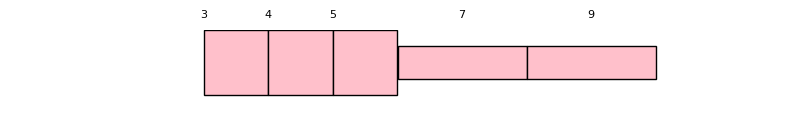

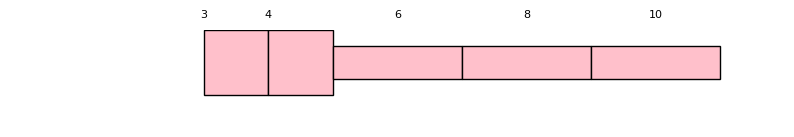

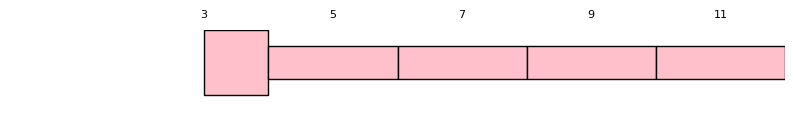

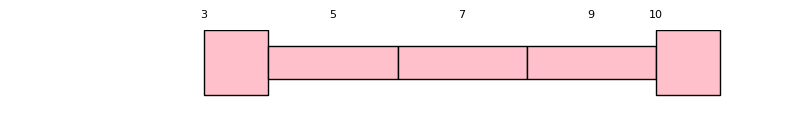

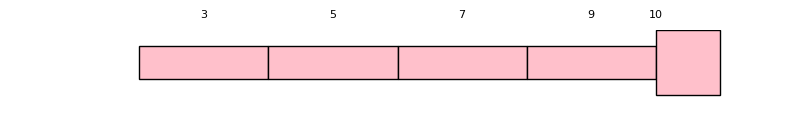

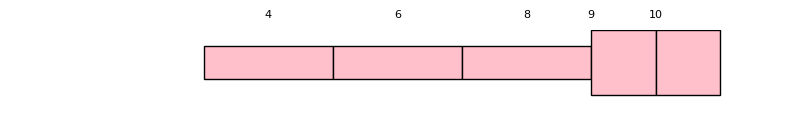

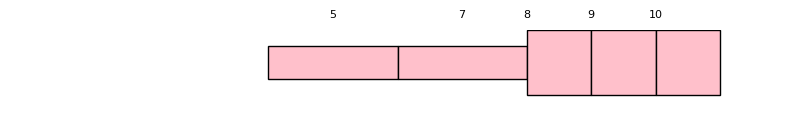

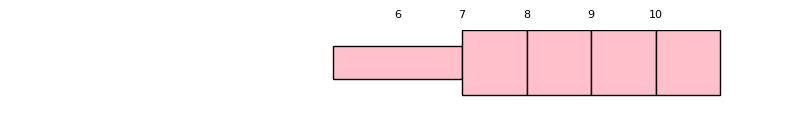

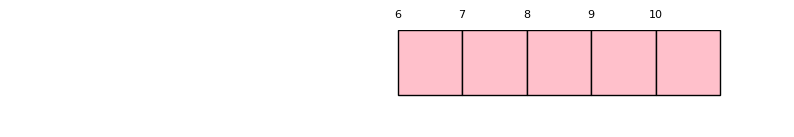

In [64]:
# Schrijf hier de code om de worm te doen bewegen.
worm.maak_segment_langer(3)
worm.teken_worm()
worm.maak_segment_langer(2)
worm.teken_worm()
worm.maak_segment_langer(1)
worm.teken_worm()
worm.maak_segment_korter(4)
worm.teken_worm()
worm.maak_segment_langer(0)
worm.teken_worm()
worm.maak_segment_korter(3)
worm.teken_worm()
worm.maak_segment_korter(2)
worm.teken_worm()
worm.maak_segment_korter(1)
worm.teken_worm()
worm.maak_segment_korter(0)
worm.teken_worm()

## De worm leren kruipen

Hierboven bedacht je zelf een reeks van bewegingen waarmee je de worm vooruit kon doen bewegen. Nu willen we de worm zelf leren om zich te verplaatsen via versterken leren. Daarvoor denken we eerst na hoe we de principes van het versterkend leren kunnen linken aan de worm. Hieronder lijsten we de verschillende principes nog eens op.

* **De agent** is diegene die de taak zal leren.
* **De omgeving** is de wereld waarin de agent zal leren.
* De omgeving heeft ook een **toestand**, dat is hoe de wereld er op dat moment uitziet.
* **De acties**: Door acties uit te voeren kan de agent de toestand van de omgeving beïnvloeden.
* **Een beloning**: Goede acties krijgen een beloning, slechte acties worden afgestraft met een negatieve beloning. Bij mensen en dieren komt een beloning overeen met de gevoelens van geluk en pijn.
* **De policy of het beleid**: Dit is de strategie die de agent op dat moment toepast. De policy legt vast welke actie de agent zal ondernemen in een gegeven toestand van de omgeving.
* **De waardefunctie**: Terwijl de beloning je een idee geeft van welke acties goed of slecht waren in een bepaalde toestand, zegt de waardefunctie iets over wat goed is op lange termijn.

**Opdracht**: Denk na over hoe je deze principes kan koppelen aan het probleem waar we de worm willen leren kruipen. Voer onderstaande codecel uit en beantwoord de vraag.

In [ ]:
vragen.stel_vraag(0)

Match de begrippen met de juiste principes van het versterkend leren.


Je bent intussen zelf in staat om te bedenken wat de agent, de omgeving, de toestand, de acties en de beloning zijn. In wat volgt willen we een **policy/beleid** leren dat de worm kan volgen om te kruipen. **De policy zegt in elke toestand welke actie de worm moet uitvoeren** (bv. maak segment 2 langer). De worm zal deze beslissing nemen op basis van de toekomstige beloning die de actie zal opleveren. **De inschatting van deze toekomstige beloning gebeurt door de waardefunctie.**

Het is deze waardefunctie die voor elke combinatie van **toestand** en **actie** zal zeggen hoe goed die actie is in die toestand. Tijdens het trainen van ons 'versterkend leren'-systeem gaan we op zoek naar deze **waardefunctie**. 

## De waardefunctie 

Zoals gezegd zal de waardefunctie voor elke combinatie van toestand en actie zeggen hoe goed die actie is in die toestand. Wiskundig kunnen we de functie dus voorstellen als een functie met twee variabelen.

\begin{equation}
Q(a, s)
\end{equation}

Waarbij $a$ de actie voorstelt en $s$ de toestand (state in het Engels). 

In ons eenvoudig systeem zullen we de waardefunctie voorstellen als een tabel. Elke rij van de tabel komt overeen met een toestand en elke kolom met een actie. Voor we de tabel kunnen opstellen moeten we dus weten hoeveel toestanden en acties er zijn. Laten we dat eens doen voor een worm met 3 segmenten.

Onze vereenvoudigde worm bestaat uit 3 segmenten, elk segment kan ofwel lang of kort zijn. Voer de volgende cellen uit en beantwoord de vragen.

In [ ]:
vragen.stel_vraag(1)

Hoeveel verschillende toestanden kan een worm met 3 segmenten hebben?


Text(value='', placeholder='Geef je antwoord hier in...')

Button(description='Antwoord indienen', style=ButtonStyle())

Output()

In [ ]:
vragen.stel_vraag(2)

Hoeveel verschillende acties zijn er mogelijk voor een worm met 3 segmenten?


Text(value='', placeholder='Geef je antwoord hier in...')

Button(description='Antwoord indienen', style=ButtonStyle())

Output()

### De Q-tabel

De tabel die we gebruiken om de waardefunctie voor te stellen, noemen we de Q-tabel. Elk element van de tabel bevat een schatting voor de toekomstige beloning voor een combinatie van een actie en een toestand. In de codecellen hieronder stellen we die tabel op.

Eerst maken we een lijst met alle mogelijke toestanden en alle mogelijke acties.

**De toestanden**

In [68]:
# De toestand van de worm stellen we voor door een opeenvolging van segmenten.
# Elk segment kan ofwel kort zijn (K) ofwel lang zijn (L).
# De product functie zal alle mogelijke combinaties van segmenten genereren.
toestanden = list(product("KL", repeat=3))
print(toestanden)

[('K', 'K', 'K'), ('K', 'K', 'L'), ('K', 'L', 'K'), ('K', 'L', 'L'), ('L', 'K', 'K'), ('L', 'K', 'L'), ('L', 'L', 'K'), ('L', 'L', 'L')]


**De acties**

In [69]:
# Elk segment heeft twee mogelijke acties: langer worden of korter worden.
# We maken een lijst die voor elk segment een langer en korter actie bevat.
acties = []
for i in range(3):
    acties.append(("L", i))
    acties.append(("K", i))
    
print(acties)

[('L', 0), ('K', 0), ('L', 1), ('K', 1), ('L', 2), ('K', 2)]


**De Q-tabel**

De Q-tabel heeft evenveel rijen als er toestanden zijn en evenveel kolommen als er acties zijn. Wanneer we starten, hebben we geen informatie over de toekomstige beloning. Daarom kiezen we willekeurige waarden voor de elementen in onze tabel.

In [70]:
# Maak een Q-tabel waar alle elementen willekeurig worden ingevuld met een waarde tussen -1 en 1.
q_tabel = np.random.uniform(-1, 1, (len(toestanden), len(acties)))
print("Q-tabel:")
print(q_tabel)

Q-tabel:
[[ 0.61303414  0.39662907  0.8017887  -0.92834494 -0.06010611 -0.91225651]
 [-0.93680034 -0.74454203  0.52242442 -0.95495205 -0.85040156  0.03137502]
 [ 0.73382742 -0.34292097  0.11413755  0.04474493 -0.80275517  0.7162508 ]
 [-0.70179949 -0.04246745  0.93789411  0.55055075  0.21029514 -0.41944057]
 [-0.33150249  0.36997184  0.94425177  0.80428037  0.75756618  0.14835015]
 [ 0.22153236  0.88780979 -0.51588325  0.79220437  0.61705934 -0.62940317]
 [ 0.30777801 -0.95046744  0.55315664  0.1324165  -0.43040013 -0.32745341]
 [-0.74189242 -0.94825442  0.17516298 -0.19688836 -0.33782605 -0.03002595]]


In *helpers.py* schreven we een functie om de Q-tabel overzichtelijk weer te geven.

In [71]:
print_q_tabel(q_tabel, toestanden, acties)

Q-tabel:
Toestand\actie	L0	K0	L1	K1	L2	K2
KKK		0.61	0.40	0.80	-0.93	-0.06	-0.91
KKL		-0.94	-0.74	0.52	-0.95	-0.85	0.03
KLK		0.73	-0.34	0.11	0.04	-0.80	0.72
KLL		-0.70	-0.04	0.94	0.55	0.21	-0.42
LKK		-0.33	0.37	0.94	0.80	0.76	0.15
LKL		0.22	0.89	-0.52	0.79	0.62	-0.63
LLK		0.31	-0.95	0.55	0.13	-0.43	-0.33
LLL		-0.74	-0.95	0.18	-0.20	-0.34	-0.03


Het is deze tabel die we later tijdens het trainingsproces zullen aanpassen.

## Een policy uitvoeren

Je vraagt je misschien af hoe een tabel in staat kan zijn om een bepaald gedrag voor te stellen. Dat kan inderdaad moeilijk zijn om te begrijpen. Om je een idee te geven over hoe dat kan, geven we hieronder een voorbeeld van een Q-tabel die een geleerd beleid/policy bevat.

We laden daarvoor een bestaande Q-tabel in uit een bestand:

In [72]:
voorbeeld_q_tabel = np.load("bestanden/q_tabel_korte_worm.npy")
print("Voorbeeld Q-tabel:")
print_q_tabel(voorbeeld_q_tabel, toestanden, acties)

Voorbeeld Q-tabel:
Q-tabel:
Toestand\actie	L0	K0	L1	K1	L2	K2
KKK		0.69	0.85	0.85	0.85	1.00	0.85
KKL		0.38	0.54	0.69	0.54	0.54	0.38
KLK		0.54	0.54	0.54	0.54	0.69	0.54
KLL		0.38	0.23	0.23	0.08	0.23	0.08
LKK		0.69	0.85	0.54	0.69	0.85	0.69
LKL		0.38	0.54	0.38	0.38	0.38	0.23
LLK		0.54	0.54	0.54	0.69	0.38	0.54
LLL		0.15	0.00	0.15	0.15	0.15	0.31


Goed, je ziet dat de Q-tabel getallen bevat. Hoe kunnen we de worm het geleerde gedrag nu laten uitvoeren?

Om een gedrag uit te voeren maak je eerst een nieuwe worm en herhaal je de volgende commando's voor een bepaald aantal stappen (bv. 20 stappen).

1. Kijk in welke toestand de worm zich nu bevind.
2. Zoek de rij in de Q-tabel die overeenkomt met deze toestand.
3. Zoek in deze rij de kolom met de hoogste waarde. 
4. Voer de actie uit die overeenkomt met deze kolom.

Hieronder geven we stap voor stap de code om het beleid in de Q-tabel uit te voeren.

#### Maak een nieuwe worm met 3 segmenten.

In [73]:
# Maak een nieuwe worm met 3 segmenten.
nieuwe_worm = Worm(3)

#### 1. Vraag de huidige toestand op van de worm.

In [74]:
# Vraag de toestand van de worm op.
toestand_worm = nieuwe_worm.toestand()
print(f"De toestand van de worm is: {toestand_worm}")

De toestand van de worm is: ('K', 'K', 'K')


#### 2. Zoek de rij in de Q-tabel die overeenkomt met deze toestand.

In [75]:
# Zoek de index van de toestand in de lijst van toestanden.
toestand_index_worm = toestanden.index(toestand_worm)
print(f"De index van de toestand in de lijst van toestanden is: {toestand_index_worm}")

# Haal op basis van de index de rij uit de Q-tabel.
rij_q_tabel = voorbeeld_q_tabel[toestand_index_worm]
print(f"De rij in de Q-tabel die overeenkomt met de toestand van de worm is: {rij_q_tabel}")

De index van de toestand in de lijst van toestanden is: 0
De rij in de Q-tabel die overeenkomt met de toestand van de worm is: [0.69204112 0.84571285 0.84571285 0.84571285 1.         0.84571285]


#### 3. Zoek in deze rij de actie met de hoogste Q waarde.

Die actie kunnen we vinden op basis van de index van de hoogste waarde. Deze index kunnen we opvragen met de *argmax()* functie. 

In [76]:
# Zoek de index van de actie met de hoogste Q-waarde in die rij.
actie_index = np.argmax(rij_q_tabel)
print(f"De index van de beste actie is: {actie_index}")

# Haal de actie op basis van de index.
beste_actie = acties[actie_index]
print(f"De beste actie is: {beste_actie}")

De index van de beste actie is: 4
De beste actie is: ('L', 2)


#### 4. Voer de actie uit

In [77]:
# Voer de actie uit op de worm.
if beste_actie[0] == "L":   # Langer worden
    nieuwe_worm.maak_segment_langer(beste_actie[1])
else:                       # Korter worden
    nieuwe_worm.maak_segment_korter(beste_actie[1])
    
# Druk de toestand van de worm na het uitvoeren van de actie.
print(f"De toestand van de worm na het uitvoeren van de actie is: {nieuwe_worm}")

De toestand van de worm na het uitvoeren van de actie is: KKL


#### Alles herhalen

We hebben nu alle code uitgevoerd om de worm een actie te laten uitvoeren op basis van de Q-tabel. Deze stappen blijven we nu herhalen. Om dat te doen kunnen we de code in een lus zetten. We slaan in elke stap ook telkens de toestand van de worm op. Zo kunnen we het kruippatroon visualiseren. Al deze code zetten we hier in een functie. Deze functie kunnen we dan later hergebruiken om de policy die jij de worm leert te visualiseren.

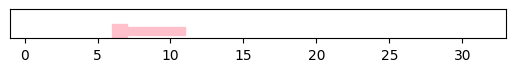

In [78]:
def voer_beleid_uit(voorbeeld_q_tabel, toestanden, acties, aantal_stappen=20, lengte_worm=3, bestandsnaam="animatie_worm.mp4"):
    """
    Voert het beleid uit dat is opgeslagen in de Q-tabel en maakt een animatie van de worm.
    :param aantal_stappen: Het aantal stappen dat de worm zal nemen.
    :param lengte_worm: De lengte van de worm waarmee het beleid wordt uitgevoerd.
    """
    stadia_van_de_worm = [] # Lijst waarin we elke tussenstaop opslaan.
    nieuwe_worm = Worm(lengte_worm)    # We beginnen met een nieuwe worm.
    stadia_van_de_worm.append(nieuwe_worm.maak_kopie())  # Voeg de starttoestand van de worm toe aan de lijst.

    # Hier overlopen we de stappen en voeren we de commando's uit die we hierboven stap voor stap hebben bepaald.
    for stap in range(aantal_stappen):
        toestand_worm = nieuwe_worm.toestand()                  # Vraag de toestand van de worm op.
        toestand_index_worm = toestanden.index(toestand_worm)   # Zoek de index van de toestand in de lijst van toestanden.
        rij_q_tabel = voorbeeld_q_tabel[toestand_index_worm]    # Haal de rij uit de Q-tabel op basis van de index.
        actie_index = np.argmax(rij_q_tabel)                    # Zoek de index van de actie met de hoogste Q-waarde in die rij.    
        beste_actie = acties[actie_index]                      # Haal de actie op basis van de index. 
        # Voer de actie uit
        if beste_actie[0] == "L":
            nieuwe_worm.maak_segment_langer(beste_actie[1])
        else:
            nieuwe_worm.maak_segment_korter(beste_actie[1])
        
        # Voeg een kopie van de huidige toestand van de worm toe aan de lijst van stadia.
        stadia_van_de_worm.append(nieuwe_worm.maak_kopie())

    # Maak een animatie van de worm.
    maak_animatie_van_worm(stadia_van_de_worm, bestandsnaam=bestandsnaam)
    
bestandsnaam = "animatie_korte_worm.mp4"
voer_beleid_uit(voorbeeld_q_tabel, toestanden, acties, aantal_stappen=20, lengte_worm=3, bestandsnaam=bestandsnaam)
Video(bestandsnaam)



## De optimale policy leren

Hierboven heb je gezien hoe je een eerder geleerd beleid/policy kan uitvoeren. In de volgende stap, laat je zelf de worm een beleid leren. De stappen die nodig zijn om een beleid te leren zijn gelijkaardig aan die om een policy uit te voeren. We voegen er echter een aantal elementen aan toe. De nieuwe code in de functie staat telkens tussen de pijlen.

Hieronder zie je de code die we hierboven gebruikt hebben om een policy uit te voeren. We hebben de naam van de functie hernoemt van `voer_beleid_uit` naar `leer_beleid`. De rest van de code is voorlopig hetzelfde. Aan deze functie voegen we stap voor stap de nodige logica toe om te kunnen leren.

In [57]:
def leer_beleid(voorbeeld_q_tabel, toestanden, acties, aantal_stappen=20, lengte_worm=3):
    stadia_van_de_worm = [] # Lijst waarin we elke tussenstaop opslaan.
    nieuwe_worm = Worm(lengte_worm)    # We beginnen met een nieuwe worm.
    stadia_van_de_worm.append(nieuwe_worm.maak_kopie())  # Voeg de starttoestand van de worm toe aan de lijst.

    # Hier overlopen we de stappen en voeren we de commando's uit die we hierboven stap voor stap hebben bepaald.
    for stap in range(aantal_stappen):
        toestand_worm = nieuwe_worm.toestand()                  # Vraag de toestand van de worm op.
        toestand_index_worm = toestanden.index(toestand_worm)   # Zoek de index van de toestand in de lijst van toestanden.
        rij_q_tabel = voorbeeld_q_tabel[toestand_index_worm]    # Haal de rij uit de Q-tabel op basis van de index.
        actie_index = np.argmax(rij_q_tabel)                    # Zoek de index van de actie met de hoogste Q-waarde in die rij.    
        beste_actie = acties[actie_index]                      # Haal de actie op basis van de index. 
        # Voer de actie uit
        if beste_actie[0] == "L":
            nieuwe_worm.maak_segment_langer(beste_actie[1])
        else:
            nieuwe_worm.maak_segment_korter(beste_actie[1])
        
        # Voeg een kopie van de huidige toestand van de worm toe aan de lijst van stadia.
        stadia_van_de_worm.append(nieuwe_worm.maak_kopie())

#### Exploratie toevoegen

Nu kiezen we ervoor om de worm altijd de beste actie te laten uitvoeren in elke toestand. Bij een eerder geleerde policy is dit goed omdat we weten dat die goed werkt. Maar wanneer de policy nog niet goed genoeg is, is het nuttig om andere mogelijkheden te exploreren. 

Deze exploratie kunnen we toevoegen door niet altijd voor de beste actie te kiezen maar door bijvoorbeeld 1/10 keer een willekeurige actie te kiezen. Dat zullen we doen door een willekeurig getal te genereren tussen 0 en 1 en te kijken of dat kleiner is dan een gegeven waarde. Deze waarde noemen we epsilon ($\epsilon$). Hoe hoger $\epsilon$, hoe waarschijnlijker het is dat we een willekeurige actie kiezen.  Deze logica voegen we hieronder toe aan de code.

In [58]:
# We voegen epsilon toe als parameter van de functie.
def leer_beleid(voorbeeld_q_tabel, toestanden, acties, epsilon=0.1, aantal_stappen=20, lengte_worm=3):
    stadia_van_de_worm = [] # Lijst waarin we elke tussenstaop opslaan.
    nieuwe_worm = Worm(lengte_worm)    # We beginnen met een nieuwe worm.
    stadia_van_de_worm.append(nieuwe_worm.maak_kopie())  # Voeg de starttoestand van de worm toe aan de lijst.

    # Hier overlopen we de stappen en voeren we de commando's uit die we hierboven stap voor stap hebben bepaald.
    for stap in range(aantal_stappen):
        toestand_worm = nieuwe_worm.toestand()                  # Vraag de toestand van de worm op.
        toestand_index_worm = toestanden.index(toestand_worm)   # Zoek de index van de toestand in de lijst van toestanden.
        rij_q_tabel = voorbeeld_q_tabel[toestand_index_worm]    # Haal de rij uit de Q-tabel op basis van de index.
        
        # -----------------------------------↓↓↓↓↓↓↓↓↓↓↓↓↓↓----------------------------------- #
        willekeurig_getal = np.random.rand()  # Genereer een willekeurig getal tussen 0 en 1.
        if willekeurig_getal < epsilon:
            # Kies een willekeurige actie (exploratie).
            actie_index = random.randint(0, len(acties) - 1)
        else:
            # Kies de beste actie op basis van de Q-tabel (exploitatie).
            actie_index = np.argmax(rij_q_tabel)                    # Zoek de index van de actie met de hoogste Q-waarde in die rij.  
              
        beste_actie = acties[actie_index]                      # Haal de actie op basis van de index. 
        # -----------------------------------↑↑↑↑↑↑↑↑↑↑↑↑↑↑----------------------------------- #
        
        # Voer de actie uit
        if beste_actie[0] == "L":
            nieuwe_worm.maak_segment_langer(beste_actie[1])
        else:
            nieuwe_worm.maak_segment_korter(beste_actie[1])
        
        # Voeg een kopie van de huidige toestand van de worm toe aan de lijst van stadia.
        stadia_van_de_worm.append(nieuwe_worm.maak_kopie())

#### De beloning van de actie vaststellen

Om te kunnen leren moeten we kunnen inschatten hoe goed een actie is. Dat doen we op basis van de ontvangen beloning. Hier kiezen we als beloning de afstand die het hoofd van de worm heeft afgelegd. In onderstaande cel voegen we de nodige code toe om de beloning vast te stellen.

In [59]:
# We voegen epsilon toe als parameter van de functie.
def leer_beleid(voorbeeld_q_tabel, toestanden, acties, epsilon=0.1, aantal_stappen=20, lengte_worm=3):
    stadia_van_de_worm = [] # Lijst waarin we elke tussenstaop opslaan.
    nieuwe_worm = Worm(lengte_worm)    # We beginnen met een nieuwe worm.
    stadia_van_de_worm.append(nieuwe_worm.maak_kopie())  # Voeg de starttoestand van de worm toe aan de lijst.

    # Hier overlopen we de stappen en voeren we de commando's uit die we hierboven stap voor stap hebben bepaald.
    for stap in range(aantal_stappen):
        toestand_worm = nieuwe_worm.toestand()                  # Vraag de toestand van de worm op.
        toestand_index_worm = toestanden.index(toestand_worm)   # Zoek de index van de toestand in de lijst van toestanden.
        rij_q_tabel = voorbeeld_q_tabel[toestand_index_worm]    # Haal de rij uit de Q-tabel op basis van de index.
        
        
        willekeurig_getal = np.random.rand()  # Genereer een willekeurig getal tussen 0 en 1.
        if willekeurig_getal < epsilon:
            # Kies een willekeurige actie (exploratie).
            actie_index = random.randint(0, len(acties) - 1)
        else:
            # Kies de beste actie op basis van de Q-tabel (exploitatie).
            actie_index = np.argmax(rij_q_tabel)                    # Zoek de index van de actie met de hoogste Q-waarde in die rij.  
              
        beste_actie = acties[actie_index]                      # Haal de actie op basis van de index. 
        
        
        # -----------------------------------↓↓↓↓↓↓↓↓↓↓↓↓↓↓----------------------------------- #
        # Sla de positie van het hoofd op voor we de actie uitvoeren.
        positie_hoofd = nieuwe_worm.positie_van_het_hoofd()
        # -----------------------------------↑↑↑↑↑↑↑↑↑↑↑↑↑↑----------------------------------- #
        
        # Voer de actie uit
        if beste_actie[0] == "L":
            nieuwe_worm.maak_segment_langer(beste_actie[1])
        else:
            nieuwe_worm.maak_segment_korter(beste_actie[1])
            
        # -----------------------------------↓↓↓↓↓↓↓↓↓↓↓↓↓↓----------------------------------- #
        # De beloning is het verschil in afstand tussen de nieuwe positie van het hoofd en de oude positie.
        beloning = nieuwe_worm.positie_van_het_hoofd() - positie_hoofd
        # -----------------------------------↑↑↑↑↑↑↑↑↑↑↑↑↑↑----------------------------------- #
        
        # Voeg een kopie van de huidige toestand van de worm toe aan de lijst van stadia.
        stadia_van_de_worm.append(nieuwe_worm.maak_kopie())

#### De Q-tabel aanpassen met behulp van de update regel.

Vervolgens moeten we de Q-tabel aanpassen. Daarvoor maken we gebruik van de update regel. De formule van deze regel zag je al eerder in het leerpad. Hieronder herhalen we de formule nog eens.

![](img/update_function_explained.png)

Een aantal elementen uit de formule hebben we al in onze code. We hebben de Q-tabel en hebben de huidige toestand en actie. Ook de beloning bij het uitvoeren van de actie kennen we. Toch zijn er nog een aantal elementen uit de formule die ontbreken.

- $\alpha$: Dit is een getal dat aangeeft hoe snel de Q-tabel aangepast moet worden op basis van de beloning. We mogen dit getal zelf kiezen dus voegen we het toe als argument aan de functie.
- $\gamma$: Dit is een getal dat aangeeft hoe belangrijk de toekomstige beloning na het uitvoeren van een actie is. Deze waarde mogen we ook zelf kiezen dus voegen we $\gamma$ ook toe als argument aan de functie.
- $\max_a Q(T_{t+1}, a)$: Dit is de Q-waarde van de beste actie in de nieuwe toestand. Het is dus een inschatting van welke beloning we kunnen verwachten in deze nieuwe toestand.

In [79]:
# We voegen epsilon toe als parameter van de functie.
def leer_beleid(voorbeeld_q_tabel, toestanden, acties, epsilon=0.1, alpha=0.1, gamma=0.9, aantal_stappen=20, lengte_worm=3):
    stadia_van_de_worm = [] # Lijst waarin we elke tussenstaop opslaan.
    nieuwe_worm = Worm(lengte_worm)    # We beginnen met een nieuwe worm.
    stadia_van_de_worm.append(nieuwe_worm.maak_kopie())  # Voeg de starttoestand van de worm toe aan de lijst.

    # Hier overlopen we de stappen en voeren we de commando's uit die we hierboven stap voor stap hebben bepaald.
    for stap in range(aantal_stappen):
        toestand_worm = nieuwe_worm.toestand()                  # Vraag de toestand van de worm op.
        toestand_index_worm = toestanden.index(toestand_worm)   # Zoek de index van de toestand in de lijst van toestanden.
        rij_q_tabel = voorbeeld_q_tabel[toestand_index_worm]    # Haal de rij uit de Q-tabel op basis van de index.
        
        
        willekeurig_getal = np.random.rand()  # Genereer een willekeurig getal tussen 0 en 1.
        if willekeurig_getal < epsilon:
            # Kies een willekeurige actie (exploratie).
            actie_index = random.randint(0, len(acties) - 1)
        else:
            # Kies de beste actie op basis van de Q-tabel (exploitatie).
            actie_index = np.argmax(rij_q_tabel)                    # Zoek de index van de actie met de hoogste Q-waarde in die rij.  
              
        beste_actie = acties[actie_index]                      # Haal de actie op basis van de index. 
        
        # Sla de positie van het hoofd op voor we de actie uitvoeren.
        positie_hoofd = nieuwe_worm.positie_van_het_hoofd()
        
        # Voer de actie uit
        if beste_actie[0] == "L":
            nieuwe_worm.maak_segment_langer(beste_actie[1])
        else:
            nieuwe_worm.maak_segment_korter(beste_actie[1])
            
        # De beloning is het verschil in afstand tussen de nieuwe positie van het hoofd en de oude positie.
        beloning = nieuwe_worm.positie_van_het_hoofd() - positie_hoofd
        
        
        # -----------------------------------↓↓↓↓↓↓↓↓↓↓↓↓↓↓----------------------------------- #
        
        # Zoek de beste waarde in de nieuwe toestand.
        nieuwe_toestand_worm = nieuwe_worm.toestand()                  # Vraag de nieuwe toestand van de worm op, na het uitvoeren van de actie.
        nieuwe_toestand_index_worm = toestanden.index(nieuwe_toestand_worm)   # Zoek de index van de nieuwe toestand in de lijst van toestanden.
        nieuwe_rij_q_tabel = voorbeeld_q_tabel[nieuwe_toestand_index_worm]    # Haal de rij uit de Q-tabel op basis van de index.
        waarde_beste_actie_nieuwe_toestand = np.max(nieuwe_rij_q_tabel)       # Zoek de beste waarde in de nieuwe toestand.
        
        # Update de Q-waarde voor de huidige toestand en actie.
        q_tabel[toestand_index_worm, actie_index] += alpha * (beloning + gamma * waarde_beste_actie_nieuwe_toestand - q_tabel[toestand_index_worm, actie_index])
        
        # -----------------------------------↑↑↑↑↑↑↑↑↑↑↑↑↑↑----------------------------------- #
        
        # Voeg een kopie van de huidige toestand van de worm toe aan de lijst van stadia.
        stadia_van_de_worm.append(nieuwe_worm.maak_kopie())
        
    return stadia_van_de_worm  # Geef de lijst van stadia terug voor animatie of verdere verwerking.
        

#### Het leerproces herhalen

Momenteel laten we de worm leren door voor een `aantal_stappen` acties uit te voeren. Wanneer de worm in een bepaalde toestand een manier heeft gevonden om vooruit te bewegen, wordt het heel moeilijk om dat ook nog vanuit andere toestanden te leren. Daarom kiezen we ervoor om dit leerproces een aantal keer te herhalen. Bij elke herhaling zetten we de worm terug in zijn begintoestand. Elke herhaling noemen we een **episode**. 

In [86]:
# We voegen de parameter eppisodes toe aan de functie om het aantal episodes te bepalen.
def leer_beleid(voorbeeld_q_tabel, toestanden, acties, epsilon=0.1, alpha=0.1, gamma=0.9, aantal_stappen=50, episodes=20, lengte_worm=3):
    stadia_van_de_worm = [] # Lijst waarin we elke tussenstaop opslaan.
    
    # -----------------------------------↓↓↓↓↓↓↓↓↓↓↓↓↓↓----------------------------------- #
    for episode in range(episodes):  # Loop over het aantal episodes.
    # -----------------------------------↑↑↑↑↑↑↑↑↑↑↑↑↑↑----------------------------------- #
        
        nieuwe_worm = Worm(lengte_worm)    # We beginnen met een nieuwe worm.
        stadia_van_de_worm.append(nieuwe_worm.maak_kopie())  # Voeg de starttoestand van de worm toe aan de lijst.

        # Hier overlopen we de stappen en voeren we de commando's uit die we hierboven stap voor stap hebben bepaald.
        for stap in range(aantal_stappen):
            toestand_worm = nieuwe_worm.toestand()                  # Vraag de toestand van de worm op.
            toestand_index_worm = toestanden.index(toestand_worm)   # Zoek de index van de toestand in de lijst van toestanden.
            rij_q_tabel = voorbeeld_q_tabel[toestand_index_worm]    # Haal de rij uit de Q-tabel op basis van de index.
            
            
            willekeurig_getal = np.random.rand()  # Genereer een willekeurig getal tussen 0 en 1.
            if willekeurig_getal < epsilon:
                # Kies een willekeurige actie (exploratie).
                actie_index = random.randint(0, len(acties) - 1)
            else:
                # Kies de beste actie op basis van de Q-tabel (exploitatie).
                actie_index = np.argmax(rij_q_tabel)                    # Zoek de index van de actie met de hoogste Q-waarde in die rij.  
                
            beste_actie = acties[actie_index]                      # Haal de actie op basis van de index. 
            
            # Sla de positie van het hoofd op voor we de actie uitvoeren.
            positie_hoofd = nieuwe_worm.positie_van_het_hoofd()
            
            # Voer de actie uit
            if beste_actie[0] == "L":
                nieuwe_worm.maak_segment_langer(beste_actie[1])
            else:
                nieuwe_worm.maak_segment_korter(beste_actie[1])
                
            # De beloning is het verschil in afstand tussen de nieuwe positie van het hoofd en de oude positie.
            beloning = nieuwe_worm.positie_van_het_hoofd() - positie_hoofd
    
            # Zoek de beste waarde in de nieuwe toestand.
            nieuwe_toestand_worm = nieuwe_worm.toestand()                  # Vraag de nieuwe toestand van de worm op, na het uitvoeren van de actie.
            nieuwe_toestand_index_worm = toestanden.index(nieuwe_toestand_worm)   # Zoek de index van de nieuwe toestand in de lijst van toestanden.
            nieuwe_rij_q_tabel = voorbeeld_q_tabel[nieuwe_toestand_index_worm]    # Haal de rij uit de Q-tabel op basis van de index.
            waarde_beste_actie_nieuwe_toestand = np.max(nieuwe_rij_q_tabel)       # Zoek de beste waarde in de nieuwe toestand.
            
            # Update de Q-waarde voor de huidige toestand en actie.
            q_tabel[toestand_index_worm, actie_index] += alpha * (beloning + gamma * waarde_beste_actie_nieuwe_toestand - q_tabel[toestand_index_worm, actie_index])
            
            # Voeg een kopie van de huidige toestand van de worm toe aan de lijst van stadia.
            stadia_van_de_worm.append(nieuwe_worm.maak_kopie())
            
    return stadia_van_de_worm  # Geef de lijst van stadia terug voor animatie of verdere verwerking.
        

#### De worm laten leren

Zo je hebt nu een functie die in staat is om de worm te laten leren op basis van de beloning. Laten we deze functie eens uitvoeren met 100 stappen en 5 episodes. Zorg er zeker voor dat je bovenstaande codecel hebt uitgevoerd!

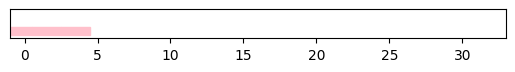

In [101]:
q_tabel = np.random.uniform(-1, 1, (len(toestanden), len(acties)))
stadia = leer_beleid(q_tabel, 
                     toestanden, 
                     acties, 
                     epsilon=0.1, 
                     alpha=0.1, 
                     gamma=0.9, 
                     aantal_stappen=100, 
                     episodes=5,
                     lengte_worm=3)
bestandsnaam = "animatie_leerproces_worm.mp4"
maak_animatie_van_worm(stadia, bestandsnaam=bestandsnaam, fps=10)
Video(bestandsnaam)

Bekijk de animatie goed! Wat doet de worm tijdens het leren. Zie je wanneer de worm een nieuwe actie exploreert en wanneer die bepaalde kennis exploiteert?

**Opdracht**: Pas de parameters van het leerproces aan en probeer ervoor te zorgen dat de worm op een efficiënte manier kruipt. Pas telkens maar één parameter per keer aan en bekijk het effect.
**Tips**:
- Voeg aan de functie `maak_animatie_van_worm()` de parameter `fps` toe. Hiermee kan je zeggen hoeveel beelden er per seconden afgespeeld moeten worden. Door deze waarde hoger te zetten, gaat de animatie sneller.
- Je kan elke animatie een andere naam geven, op die manier kan je ze later opnieuw bekijken en vergelijken.
- Let op: Wanneer je een hoog aantal episodes en stappen kiest, kan het lang duren om de code uit te voeren.

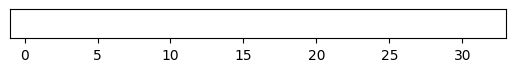

In [102]:
q_tabel = np.random.uniform(-1, 1, (len(toestanden), len(acties)))
stadia = leer_beleid(q_tabel, 
                     toestanden, 
                     acties, 
                     epsilon=0.2, 
                     alpha=0.1, 
                     gamma=0.9, 
                     aantal_stappen=500, 
                     episodes=10,
                     lengte_worm=3)

bestandsnaam = "animatie_leerproces_worm.mp4"
maak_animatie_van_worm(stadia, bestandsnaam=bestandsnaam, fps=10)
Video(bestandsnaam)

#### Voer het geleerde beleid uit

Als het je gelukt is om ervoor te zorgen dat de worm vooruit kruipt, kan je het geleerde beleid ook uitvoeren. Daarvoor schreven we eerder al de functie `voer_beleid_uit()`.

**Opdracht**: Gebruik onderstaande codecel om het beleid dat de worm geleerd heeft uit te voeren en te visualiseren. Doe dat voor 30 stappen. Heeft de worm 

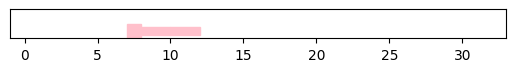

In [103]:
bestandsnaam = "animatie_worm_na_leerproces.mp4"
voer_beleid_uit(q_tabel,
                toestanden, 
                acties, 
                aantal_stappen=30, 
                lengte_worm=3, 
                bestandsnaam=bestandsnaam)
Video(bestandsnaam)

# Partners

Dit lesmateriaal maakt deel uit van het wAIsda? project van Dwengo en wordt gefinancierd met steun van VLAIO.

![](img/vlaio.png)
![](img/dwengo-groen-zwart.png)